In [28]:
import numpy as np
import matplotlib.pyplot as plt

In [29]:
plt.style.use('seaborn-v0_8-colorblind')
colors = [plt.plot(0, 0)[0].get_color() for i in range(20)]
plt.close()

plt.style.use('ggplot')

In [30]:
(np.arange(2,15,2)*0.7**3/14)**(1/3)

array([0.36593057, 0.46104363, 0.52776321, 0.58087857, 0.62573247,
       0.66493998, 0.7       ])

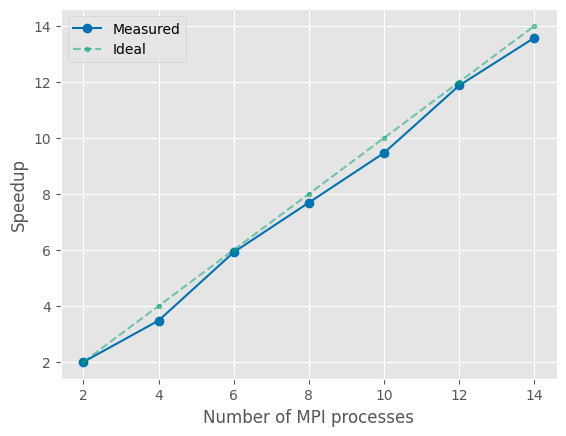

In [31]:
with open("Weak_scaling_output.txt", "r") as f:
    data = f.read()
grids =[grid.split('\n')[0] for grid in data.split("Grid size: ")[1:]]
grid_x, grid_y = zip(*[map(int, grid.split(' x ')) for grid in grids])
sm = [int(x.split('\n')[0]) for x in data.split("./run_tsunami.sh ")[1:]]
avg_time = [float(x.split(' ns/')[0]) for x in data.split("Average performance is ")[1:]]

times = np.array(avg_time)*np.array(grid_x)*np.array(grid_y)*1e-9
plt.plot(sm, avg_time[0]/np.array(avg_time)*np.arange(2,15,2), marker='o', color = colors[0], label = "Measured")
plt.plot(np.arange(2,15,2), np.arange(2,15,2), marker='o', color = colors[1], label = "Ideal", markersize=3, linestyle='dashed', alpha = 0.5)
plt.legend()
plt.xlabel("Number of MPI processes")
plt.ylabel("Speedup");

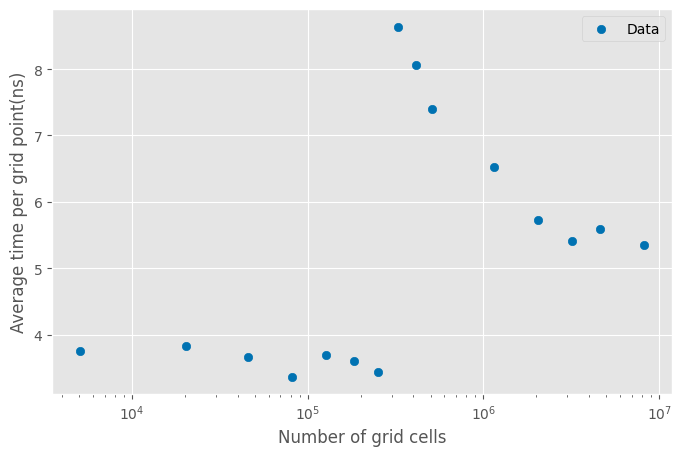

In [37]:
#min_workload_size
scales = [1, 2, 3, 4, 0.5, 1.5, 2.5, 0.1, 0.2, 0.3, 0.4, 0.6, 0.7, 0.8, 0.9]

with open("min_workload_size.txt", "r") as f:
    data = f.read()
    
grids =[grid.split('\n')[0] for grid in data.split("Grid size: ")[1:]]
grid_x, grid_y = zip(*[map(int, grid.split(' x ')) for grid in grids])
sm = [int(x.split('\n')[0]) for x in data.split("./run_tsunami.sh ")[1:]]
avg_time = np.array([float(x.split(' ns/')[0]) for x in data.split("Average performance is ")[1:]])

grid_size = np.array(grid_x)*np.array(grid_y)




fig, axs = plt.subplots(1, figsize=(8, 5))

axs.scatter(grid_size, avg_time, marker='o', label = 'Data', color = colors[0])
axs.set_xscale('log')
axs.set_xlabel('Number of grid cells')
axs.set_ylabel('Average time per grid point(ns)')
min_work_size = grid_size[np.where(avg_time < 5)[0]][-1]
# axs.axvline(min_work_size, color=colors[1], linestyle='--', label=f'Minimum workload size={min_work_size}')
axs.legend();


'#E24A33'

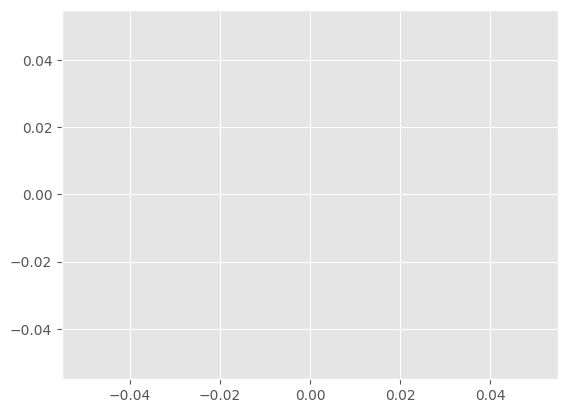

In [ ]:
plt.plot(0, 0)[0].get_color()